## HW3

1. Скачайте 1079 геномов из 30 российских популяций с сайта http://
www.russiangenome.ru/
2. Сделайте LD-pruning с помощью PLINK (скачивается бинарный файл)
3. С помощью PLINK посчитайте и визуализируйте матрицу с FST
4. Используйте инструмент ADMIXTURE, чтобы получить ADMIXTURE-plot
4. Какой K вы выбрали? Обоснуйте.
5. Проанализируйте ADMIXTURE-plot? Соответствует ли он Вашим представлениям о
древних донорских популяциях, сформировавших современные? Сравните результаты
с PCA из предыдущего домашнего задания.

Начало тут такое же как и в ДЗ2 - в data уже скачан датасет. Делаем qc/ld-pruning -> получаем `qc_pruned` версию, в общем всё, кроме PCA.

#### Задание 1

 Скачал датасет и положил в DATA_PREFIX (ниже в коде)

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import subprocess

import pandas as pd
import numpy as np

In [ ]:
PLINK2 = Path("plink2_mac_arm64_20260228/plink2")
DATA_PREFIX = Path("biengi/biengi")
OUT_DIR = Path("biengi/results")
OUT_DIR.mkdir(exist_ok=True)

# Такая же утилита для прогона команд из ОС над бинарем - даёт передавать значения флагов и вывод в ячейку
def run_plink2(args):
    cmd = [str(PLINK2), *map(str, args)]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError("plink2 failed command on binary")
    if result.stdout:
        print(result.stdout)

    return result

#### Задание 2

Делаем QC + LD-Pruning, как в прошлой дз

In [14]:
qc_prefix = OUT_DIR / "qc"
run_plink2([
    "--bfile", DATA_PREFIX,
    "--geno", 0.1,
    "--mind", 0.1,
    "--maf", 0.05,
    "--make-bed",
    "--out", qc_prefix,
])


PLINK v2.0.0-a.6.33 M1 (28 Feb 2026)                cog-genomics.org/plink/2.0/
(C) 2005-2026 Shaun Purcell, Christopher Chang    GNU General Public License v3
Logging to biengi/results/qc.log.
Options in effect:
  --bfile biengi/biengi
  --geno 0.1
  --maf 0.05
  --make-bed
  --mind 0.1
  --out biengi/results/qc

Start time: Wed Apr 22 01:27:24 2026
32768 MiB RAM detected; reserving 16384 MiB for main workspace.
Using up to 12 threads (change this with --threads).
894 samples (320 females, 574 males; 894 founders) loaded from
biengi/biengi.fam.
242180 variants loaded from biengi/biengi.bim.
Note: No phenotype data present.
Calculating sample missingness rates... 275481done.
0 samples removed due to missing genotype data (--mind).
894 samples (320 females, 574 males; 894 founders) remaining after main
filters.
Calculating allele frequencies... 275481done.
--geno: 0 variants removed due to missing genotype data.
7474 variants removed due to allele frequency threshold(s)
(--maf/--max-maf

CompletedProcess(args=['plink2_mac_arm64_20260228/plink2', '--bfile', 'biengi/biengi', '--geno', '0.1', '--mind', '0.1', '--maf', '0.05', '--make-bed', '--out', 'biengi/results/qc'], returncode=0, stdout='PLINK v2.0.0-a.6.33 M1 (28 Feb 2026)                cog-genomics.org/plink/2.0/\n(C) 2005-2026 Shaun Purcell, Christopher Chang    GNU General Public License v3\nLogging to biengi/results/qc.log.\nOptions in effect:\n  --bfile biengi/biengi\n  --geno 0.1\n  --maf 0.05\n  --make-bed\n  --mind 0.1\n  --out biengi/results/qc\n\nStart time: Wed Apr 22 01:27:24 2026\n32768 MiB RAM detected; reserving 16384 MiB for main workspace.\nUsing up to 12 threads (change this with --threads).\n894 samples (320 females, 574 males; 894 founders) loaded from\nbiengi/biengi.fam.\n242180 variants loaded from biengi/biengi.bim.\nNote: No phenotype data present.\nCalculating sample missingness rates... 0%\x08\x0827%\x08\x08\x0854%\x08\x08\x0881%\x08\x08\x08done.\n0 samples removed due to missing genotype d

In [15]:
prune_prefix = OUT_DIR / "pruned"
run_plink2([
    "--bfile", qc_prefix,
    "--indep-pairwise", 50, 5, 0.2,
    "--out", prune_prefix,
])

PLINK v2.0.0-a.6.33 M1 (28 Feb 2026)                cog-genomics.org/plink/2.0/
(C) 2005-2026 Shaun Purcell, Christopher Chang    GNU General Public License v3
Logging to biengi/results/pruned.log.
Options in effect:
  --bfile biengi/results/qc
  --indep-pairwise 50 5 0.2
  --out biengi/results/pruned

Start time: Wed Apr 22 01:27:26 2026
32768 MiB RAM detected; reserving 16384 MiB for main workspace.
Using up to 12 threads (change this with --threads).
894 samples (320 females, 574 males; 894 founders) loaded from
biengi/results/qc.fam.
234706 variants loaded from biengi/results/qc.bim.
Note: No phenotype data present.
Calculating allele frequencies... 275583done.
--indep-pairwise (11 compute threads): 50160040/234706 variants removed.
Writing...
Variant lists written to biengi/results/pruned.prune.in and
biengi/results/pruned.prune.out .
End time: Wed Apr 22 01:27:26 2026



CompletedProcess(args=['plink2_mac_arm64_20260228/plink2', '--bfile', 'biengi/results/qc', '--indep-pairwise', '50', '5', '0.2', '--out', 'biengi/results/pruned'], returncode=0, stdout='PLINK v2.0.0-a.6.33 M1 (28 Feb 2026)                cog-genomics.org/plink/2.0/\n(C) 2005-2026 Shaun Purcell, Christopher Chang    GNU General Public License v3\nLogging to biengi/results/pruned.log.\nOptions in effect:\n  --bfile biengi/results/qc\n  --indep-pairwise 50 5 0.2\n  --out biengi/results/pruned\n\nStart time: Wed Apr 22 01:27:26 2026\n32768 MiB RAM detected; reserving 16384 MiB for main workspace.\nUsing up to 12 threads (change this with --threads).\n894 samples (320 females, 574 males; 894 founders) loaded from\nbiengi/results/qc.fam.\n234706 variants loaded from biengi/results/qc.bim.\nNote: No phenotype data present.\nCalculating allele frequencies... 0%\x08\x0827%\x08\x08\x0855%\x08\x08\x0883%\x08\x08\x08done.\n--indep-pairwise (11 compute threads): 0%\x08\x0850%\x08\x08\x08160040/2347

In [16]:
qc_pruned_prefix = OUT_DIR / "qc_pruned"
run_plink2([
    "--bfile", qc_prefix,
    "--extract", f"{prune_prefix}.prune.in",
    "--make-bed",
    "--out", qc_pruned_prefix,
])

PLINK v2.0.0-a.6.33 M1 (28 Feb 2026)                cog-genomics.org/plink/2.0/
(C) 2005-2026 Shaun Purcell, Christopher Chang    GNU General Public License v3
Logging to biengi/results/qc_pruned.log.
Options in effect:
  --bfile biengi/results/qc
  --extract biengi/results/pruned.prune.in
  --make-bed
  --out biengi/results/qc_pruned

Start time: Wed Apr 22 01:27:28 2026
32768 MiB RAM detected; reserving 16384 MiB for main workspace.
Using up to 12 threads (change this with --threads).
894 samples (320 females, 574 males; 894 founders) loaded from
biengi/results/qc.fam.
234706 variants loaded from biengi/results/qc.bim.
Note: No phenotype data present.
--extract: 74666 variants remaining.
74666 variants remaining after main filters.
Writing biengi/results/qc_pruned.fam ... done.
Writing biengi/results/qc_pruned.bim ... done.
Writing biengi/results/qc_pruned.bed ... 275382done.
End time: Wed Apr 22 01:27:28 2026



CompletedProcess(args=['plink2_mac_arm64_20260228/plink2', '--bfile', 'biengi/results/qc', '--extract', 'biengi/results/pruned.prune.in', '--make-bed', '--out', 'biengi/results/qc_pruned'], returncode=0, stdout='PLINK v2.0.0-a.6.33 M1 (28 Feb 2026)                cog-genomics.org/plink/2.0/\n(C) 2005-2026 Shaun Purcell, Christopher Chang    GNU General Public License v3\nLogging to biengi/results/qc_pruned.log.\nOptions in effect:\n  --bfile biengi/results/qc\n  --extract biengi/results/pruned.prune.in\n  --make-bed\n  --out biengi/results/qc_pruned\n\nStart time: Wed Apr 22 01:27:28 2026\n32768 MiB RAM detected; reserving 16384 MiB for main workspace.\nUsing up to 12 threads (change this with --threads).\n894 samples (320 females, 574 males; 894 founders) loaded from\nbiengi/results/qc.fam.\n234706 variants loaded from biengi/results/qc.bim.\nNote: No phenotype data present.\n--extract: 74666 variants remaining.\n74666 variants remaining after main filters.\nWriting biengi/results/qc_

#### QC и LD-pruning

После фильтрации по missingness и MAF число SNP уменьшилось с 242180 до 234706.  
После LD-pruning для дальнейшего популяционного анализа осталось 74666 SNP.

LD-pruning был необходим, чтобы уменьшить избыточную коррелированность маркеров и сделать результаты ADMIXTURE и FST более устойчивыми и интерпретируемыми.


#### Задание 3

С помощью PLINK надо посчитать и визуализировать матрицу с FST

Для того чтобы сработал FST нам нужно сформировать файлик с фенотипами (для удобства делаем отдельную .tsv)

In [23]:
pop_file = OUT_DIR / "populations.tsv"

pd.read_csv(
    DATA_PREFIX.with_suffix(".pedind"),
    sep=r"\s+",
    header=None,
    usecols=[0, 1, 5],
    names=["FID", "IID", "POP"],
).to_csv(pop_file, sep="\t", index=False)


In [25]:
fst_prefix = OUT_DIR / "fst_res"
run_plink2([
    "--bfile", qc_pruned_prefix,
    "--pheno", pop_file,
    "--pheno-name", "POP",
    "--fst", "POP",
    "--out", fst_prefix,
])


PLINK v2.0.0-a.6.33 M1 (28 Feb 2026)                cog-genomics.org/plink/2.0/
(C) 2005-2026 Shaun Purcell, Christopher Chang    GNU General Public License v3
Logging to biengi/results/fst_res.log.
Options in effect:
  --bfile biengi/results/qc_pruned
  --fst POP
  --out biengi/results/fst_res
  --pheno biengi/results/populations.tsv
  --pheno-name POP

Start time: Wed Apr 22 01:40:16 2026
32768 MiB RAM detected; reserving 16384 MiB for main workspace.
Using up to 12 threads (change this with --threads).
894 samples (320 females, 574 males; 894 founders) loaded from
biengi/results/qc_pruned.fam.
74666 variants loaded from biengi/results/qc_pruned.bim.
1 categorical phenotype loaded (894 values).
--fst: Analyzing 894 samples across 28 populations.
Autosomal --fst: 87done.
Autosomal --fst: Summary written to biengi/results/fst_res.fst.summary .
End time: Wed Apr 22 01:40:16 2026



CompletedProcess(args=['plink2_mac_arm64_20260228/plink2', '--bfile', 'biengi/results/qc_pruned', '--pheno', 'biengi/results/populations.tsv', '--pheno-name', 'POP', '--fst', 'POP', '--out', 'biengi/results/fst_res'], returncode=0, stdout='PLINK v2.0.0-a.6.33 M1 (28 Feb 2026)                cog-genomics.org/plink/2.0/\n(C) 2005-2026 Shaun Purcell, Christopher Chang    GNU General Public License v3\nLogging to biengi/results/fst_res.log.\nOptions in effect:\n  --bfile biengi/results/qc_pruned\n  --fst POP\n  --out biengi/results/fst_res\n  --pheno biengi/results/populations.tsv\n  --pheno-name POP\n\nStart time: Wed Apr 22 01:40:16 2026\n32768 MiB RAM detected; reserving 16384 MiB for main workspace.\nUsing up to 12 threads (change this with --threads).\n894 samples (320 females, 574 males; 894 founders) loaded from\nbiengi/results/qc_pruned.fam.\n74666 variants loaded from biengi/results/qc_pruned.bim.\n1 categorical phenotype loaded (894 values).\n--fst: Analyzing 894 samples across 2

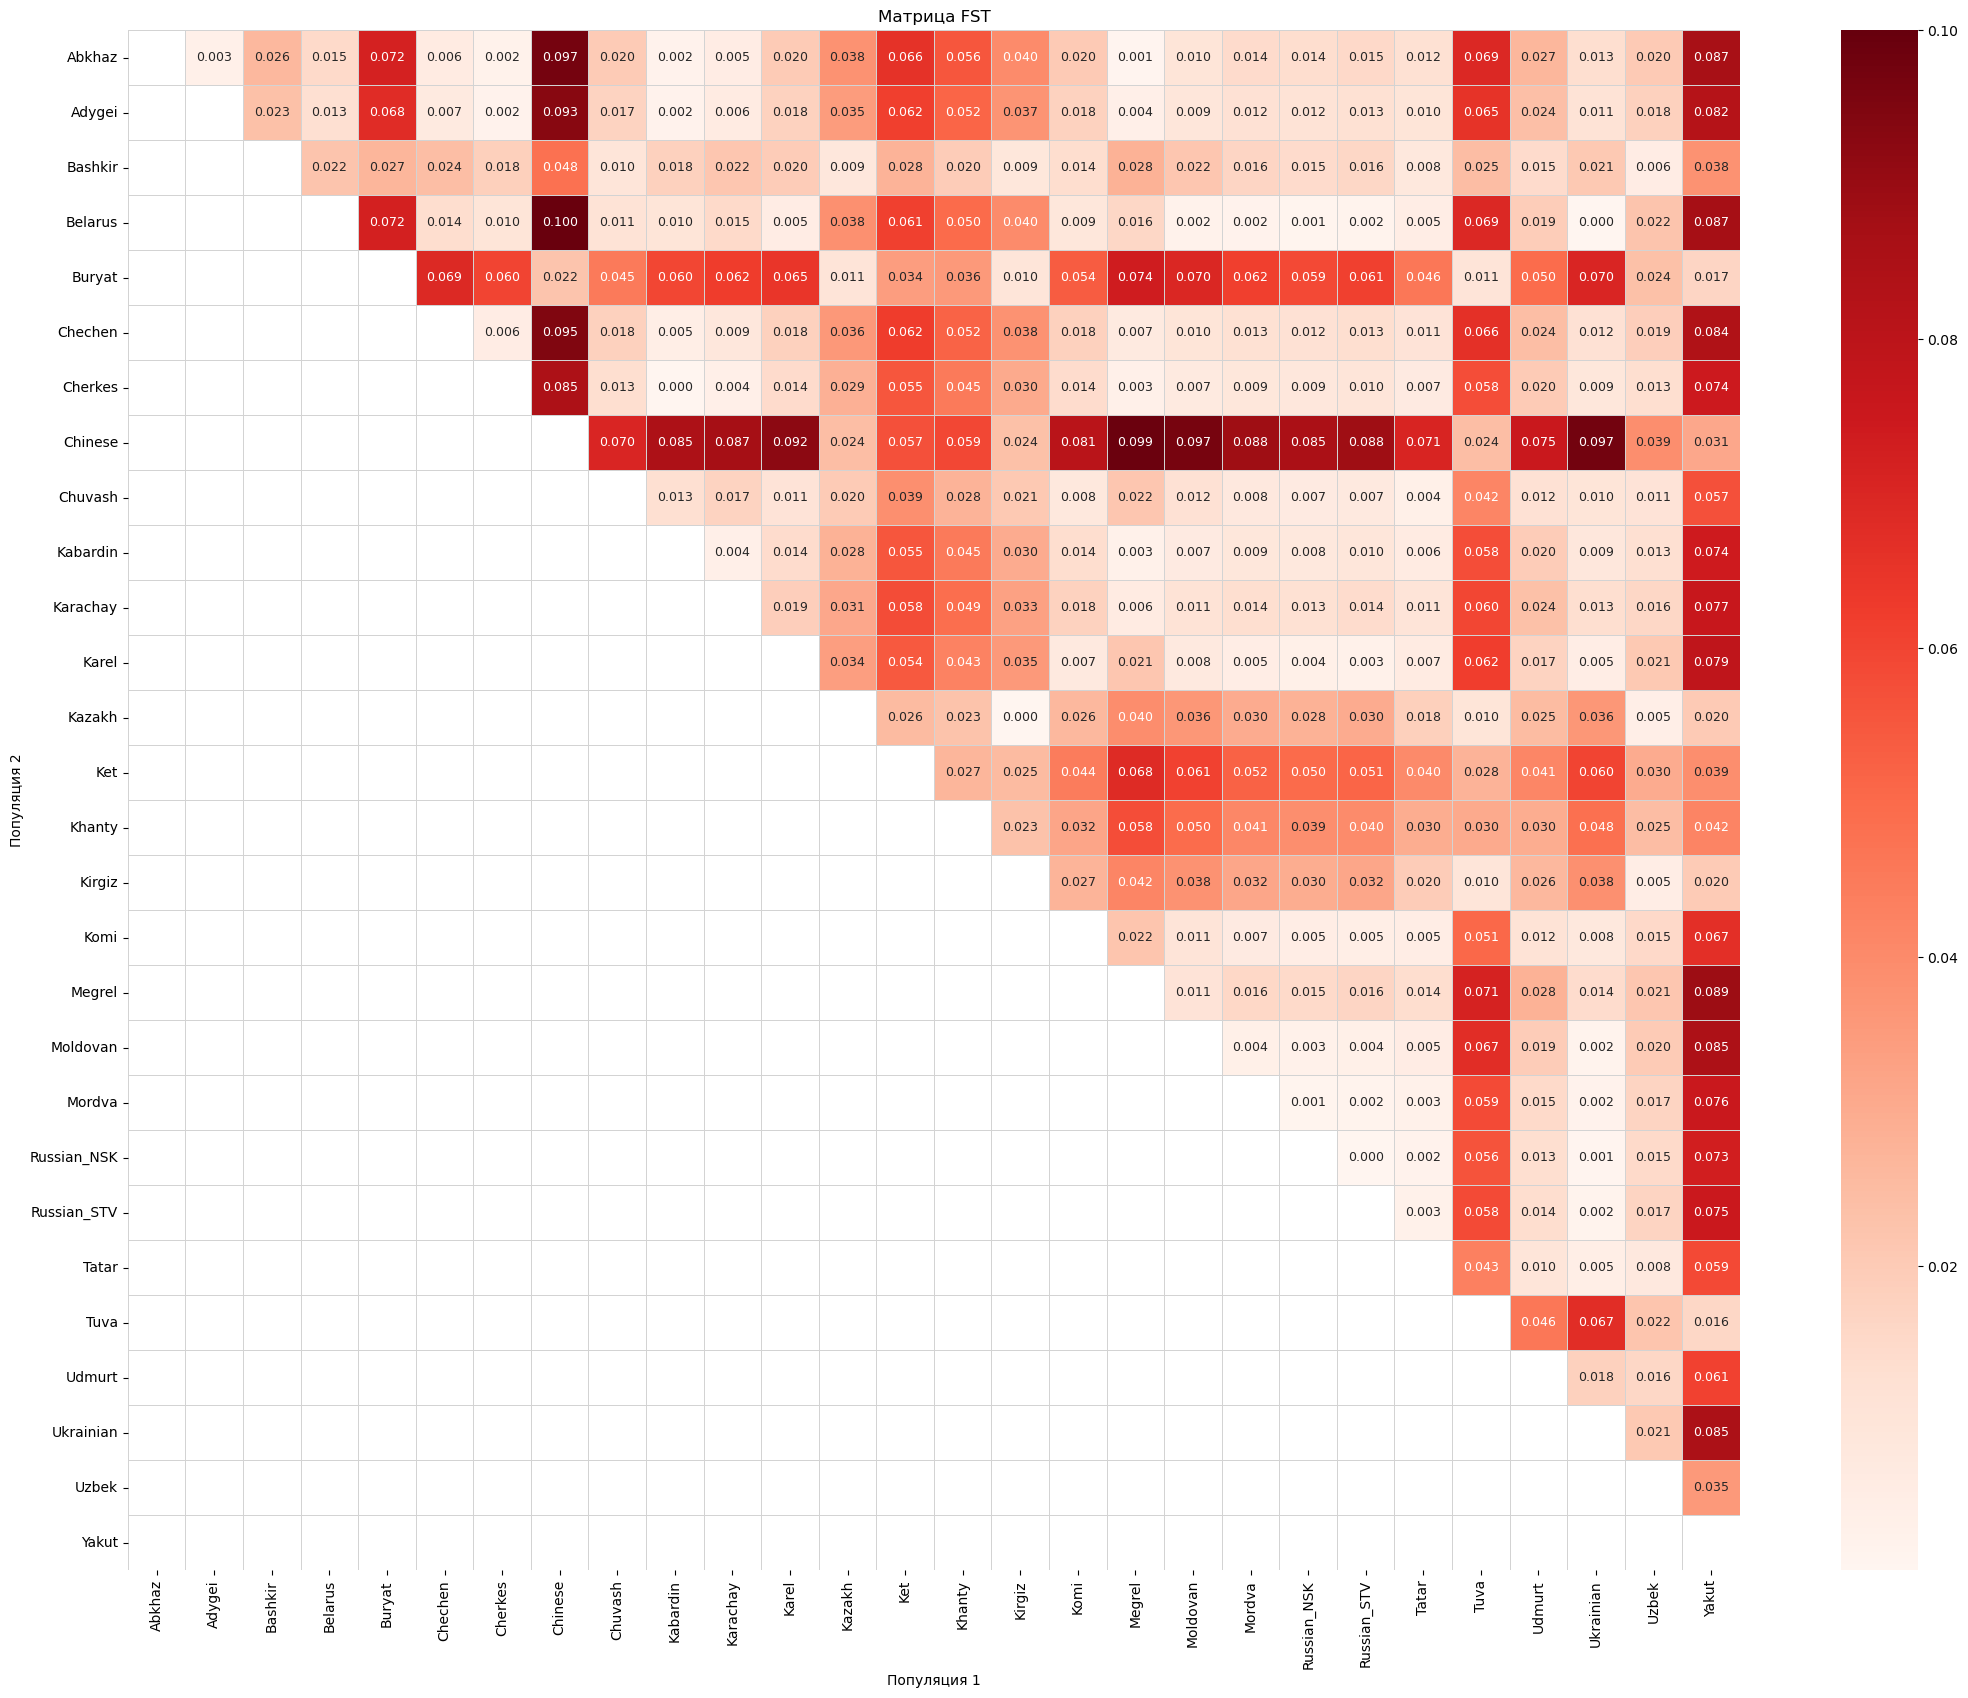

In [49]:
fst = pd.read_csv(str(fst_prefix) + ".fst.summary", sep="\t")
fst.columns = ["Pop1", "Pop2", "FST"]

matrix = fst.pivot(index="Pop1", columns="Pop2", values="FST")
# Делаем матрицу квадратной, взяв сет от популяций
all_pops = sorted(list(set(matrix.index) | set(matrix.columns)))
matrix = matrix.reindex(index=all_pops, columns=all_pops)

matrix = matrix.fillna(0)
# симметрия для читаемости
matrix_sym = matrix + matrix.T
# также для читаемости сносим диагональ
np.fill_diagonal(matrix_sym.values, np.nan)

plt.figure(figsize=(26, 20))

mask = np.tril(np.ones_like(matrix, dtype=bool))
sns.heatmap(
    matrix,
    fmt='.3f',
    annot=True,
    mask=mask,
    cmap='Reds',
    linewidths=0.5,
    linecolor='lightgrey',
    annot_kws={"size": 9},
    vmax=0.100
)

plt.title('Матрица FST')
plt.xlabel('Популяция 1')
plt.ylabel('Популяция 2')
plt.show()


#### Интерпретация матрицы FST

По матрице FST видно, что наиболее близкими оказываются географически и исторически близкие популяции. Например, очень низкие значения наблюдаются между кавказскими популяциями: абхазы, адыгейцы, черчесы, кабардины и мегрельцы. Это говорит о слабой генетической дифференциации внутри этой группы.

Также низкие значения FST наблюдаются между восточнославянскими и близкими к ним популяциями, например между беларусы, уркаинцы, новосибирские русские и ставропольские, а также между мордвийцами, респ коми и рядом соседних групп. Это указывает на их относительную генетическую близость.

Наоборот, наиболее высокие значения FST наблюдаются между европейско-кавказскими популяциями и более восточными/сибирскими группами, такими как китайцы, тувинцы и якуты. Особенно заметно выделяется якуты, для которого значения FST с большинством западных популяций остаются высокими. Это отражает более сильную генетическую обособленность этих групп.

Интересно, что тюркские и урало-сибирские популяции, такие как башкиры, татары, казахи, киргизы и узбеки, часто занимают промежуточное положение: они не так близки к восточнославянским популяциям, как последние между собой, но и не так далеки, как якуты или китайцы. Это хорошо согласуется с их промежуточным географическим и историческим положением.

В целом матрица FST показывает, что в данных присутствует выраженная популяционная структура: можно выделить как минимум кавказский кластер, восточнославянско-европейский кластер и более восточные/сибирские группы, между которыми наблюдается заметная генетическая дифференциация.

#### Задание 4

Используйте инструмент ADMIXTURE, чтобы получить ADMIXTURE-plot

Далее качаем бинарь ADMIXTURE с просторов интернета. Накидываем такую же subprocess утилитку на питоне.

P.S оказывается в PLINK2.0 был ADMXTURE, но я скачал в целом нормальную версию того же EM алгоритма.

In [55]:
ADMIXTURE = Path("dist/admixture_macosx-1.3.0/admixture")


def run_admixture(args):
    cmd = [str(ADMIXTURE), *map(str, args)]
    result = subprocess.run(cmd, text=True)
    if result.returncode != 0:
        raise RuntimeError("admixture failed command on binary")
    return result


Далее задаём число K и вызываем бинарь

In [ ]:
def run_all_admixes():
    # 2 и 3 запускал ранее при тестировании без paralleling и с меньшим delta (C)
    for k in range(4, 8):
        run_admixture([
        "-j11",
        "-C", "0.1",
        f"{qc_pruned_prefix}.bed",
        k,
    ])

run_all_admixes()

****                   ADMIXTURE Version 1.3.0                  ****
****                    Copyright 2008-2015                     ****
****           David Alexander, Suyash Shringarpure,            ****
****                John  Novembre, Ken Lange                   ****
****                                                            ****
****                 Please cite our paper!                     ****
****   Information at www.genetics.ucla.edu/software/admixture  ****

Parallel execution requested.  Will use 11 threads.
Random seed: 43
Point estimation method: Block relaxation algorithm
Convergence acceleration algorithm: QuasiNewton, 3 secant conditions
Point estimation will terminate when objective function delta < 0.1
Estimation of standard errors disabled; will compute point estimates only.
Size of G: 894x74666
Performing five EM steps to prime main algorithm
1 (EM) 	Elapsed: 18.958	Loglikelihood: -7.60948e+07	(delta): 2.76505e+07
2 (EM) 	Elapsed: 17.408	Loglikelihood: -7

In [ ]:
def load_meta(fam_path, pop_path):
    fam = pd.read_csv(fam_path, sep=r"\s+", header=None)
    fam = fam.iloc[:, :2]
    fam.columns = ["FID", "IID"]

    pop = pd.read_csv(pop_path, sep="\t")
    meta = fam.merge(pop, on=["FID", "IID"], how="left")

    return meta

def load_q(q_path, k):
    q = pd.read_csv(q_path, sep=r"\s+", header=None)
    q.columns = [f"comp_{i+1}" for i in range(k)]

    return q

def prepare_q_dataframe(k, fam_path, pop_path, q_path):
    meta = load_meta(fam_path, pop_path)
    q = load_q(q_path, k)
    df = pd.concat([meta, q], axis=1)
    # Сортируем по популяции, чтобы потом отрисовать все популяции областями
    df = df.sort_values("POP").reset_index(drop=True)

    return df

def plot_q_by_population(df, k, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(24, 5))

    comp_cols = [f"comp_{i+1}" for i in range(k)]
    x = np.arange(len(df))
    bottom = np.zeros(len(df))

    for col in comp_cols:
        ax.bar(x, df[col].values, bottom=bottom, width=1.0, linewidth=0)
        bottom += df[col].values

    pop_sizes = df.groupby("POP", sort=False).size()
    boundaries = pop_sizes.cumsum().iloc[:-1].values
    centers = pop_sizes.cumsum() - pop_sizes / 2

    for b in boundaries:
        ax.axvline(b - 0.5, color="black", linewidth=1.5)

    ax.set_xticks(centers.values)
    ax.set_xticklabels(centers.index, rotation=90)
    ax.set_xlim(-0.5, len(df) - 0.5)
    ax.set_ylim(0, 1)
    ax.set_ylabel(f"K={k}")


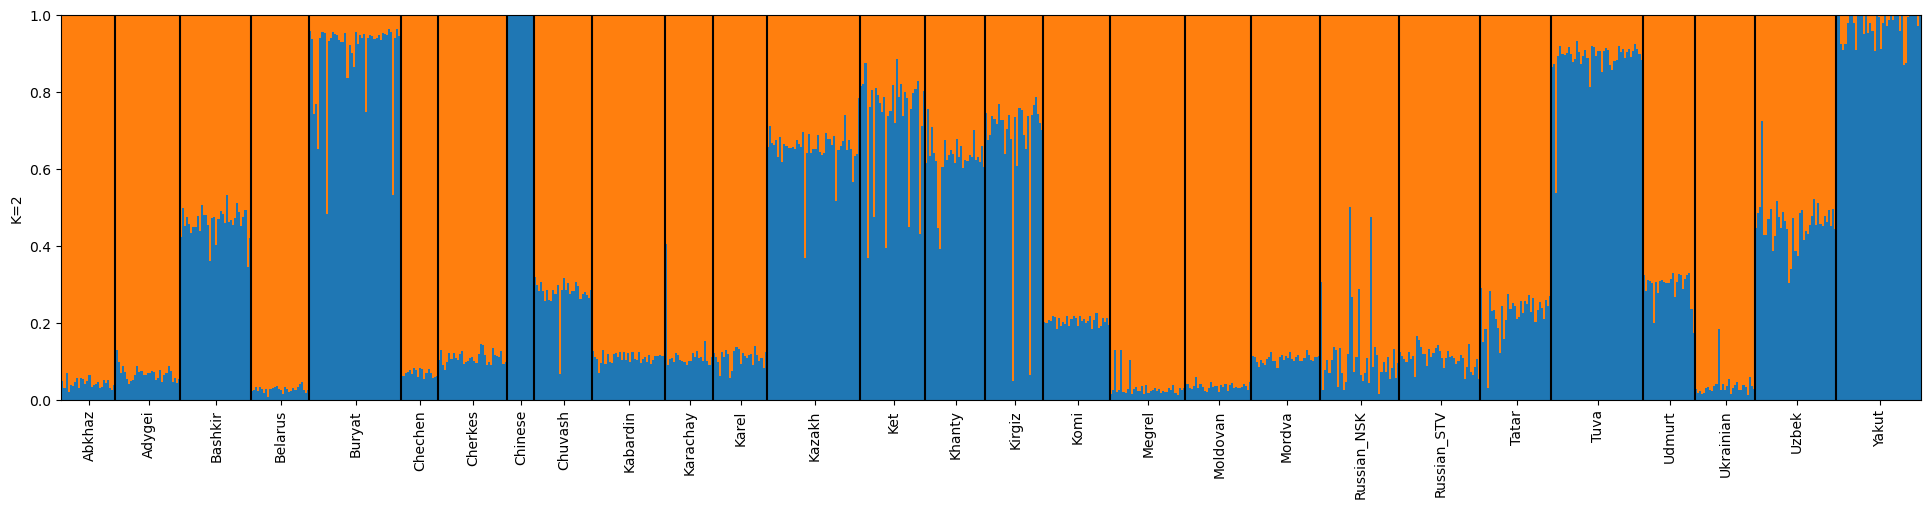

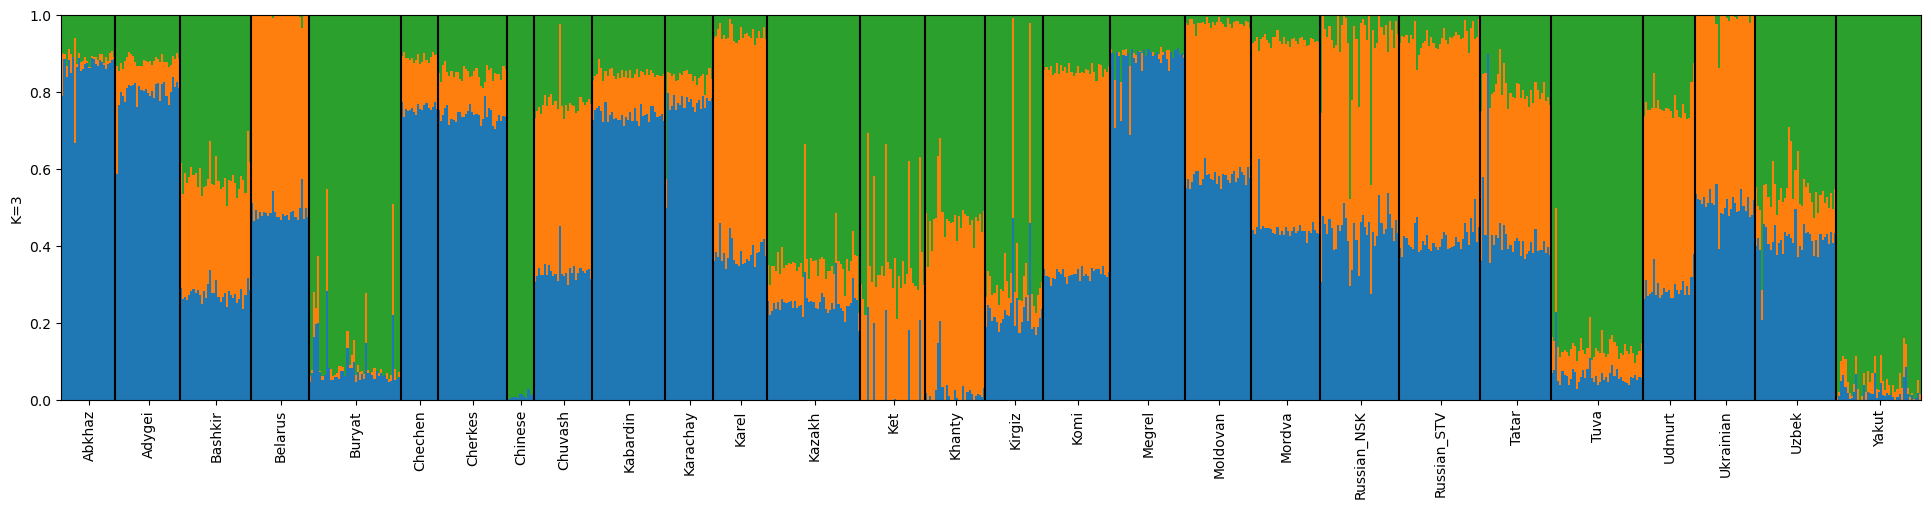

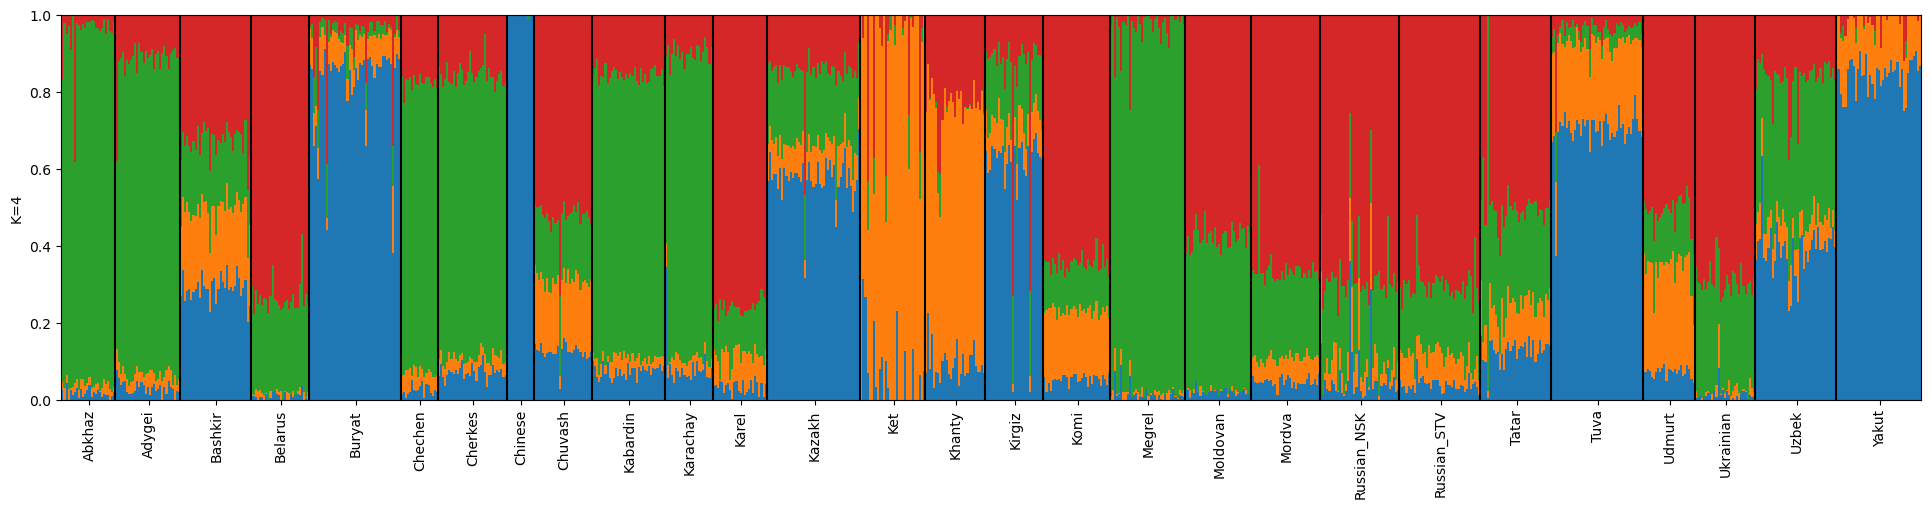

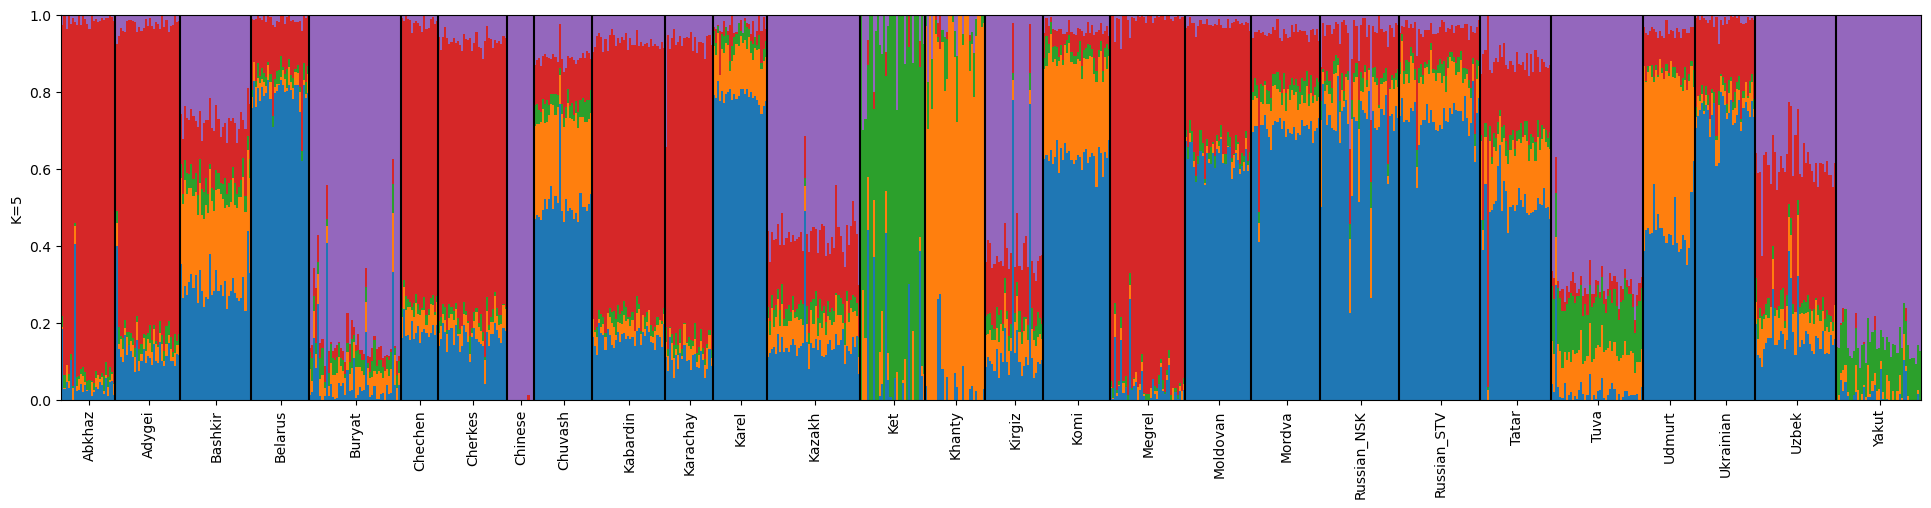

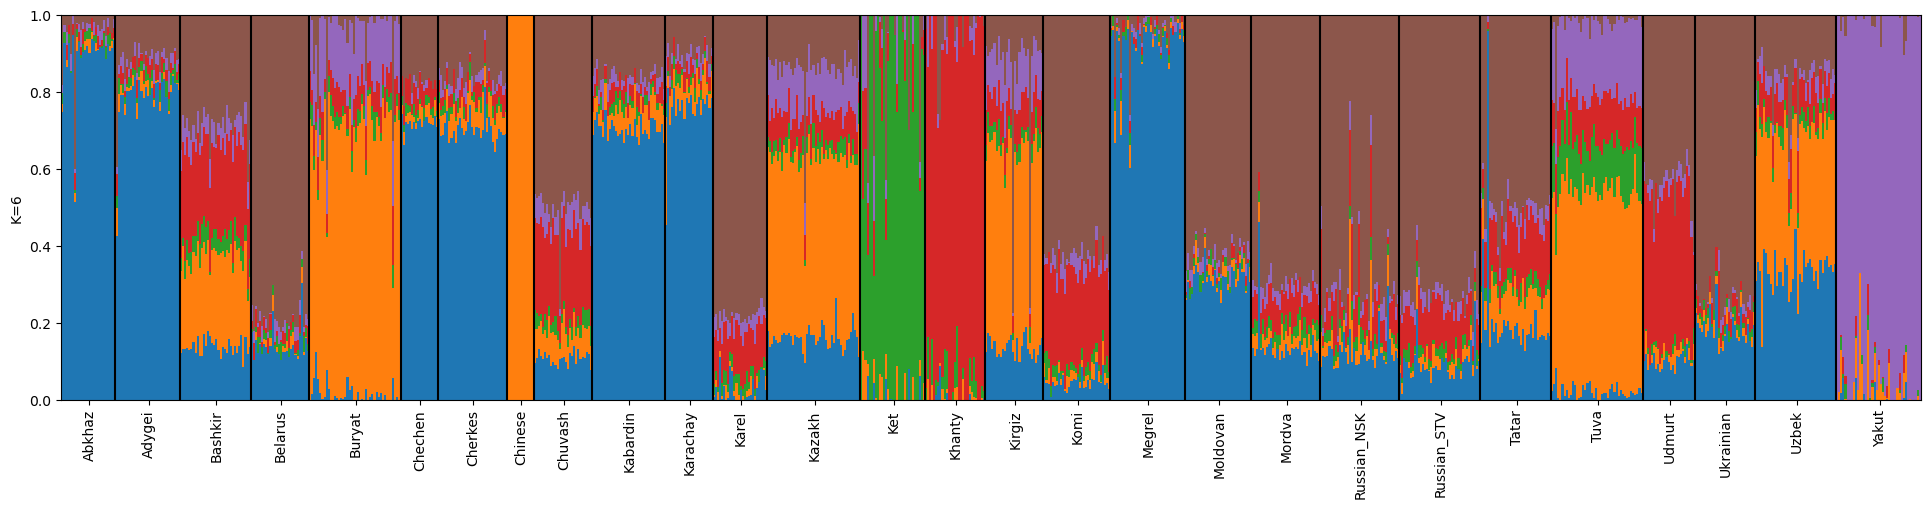

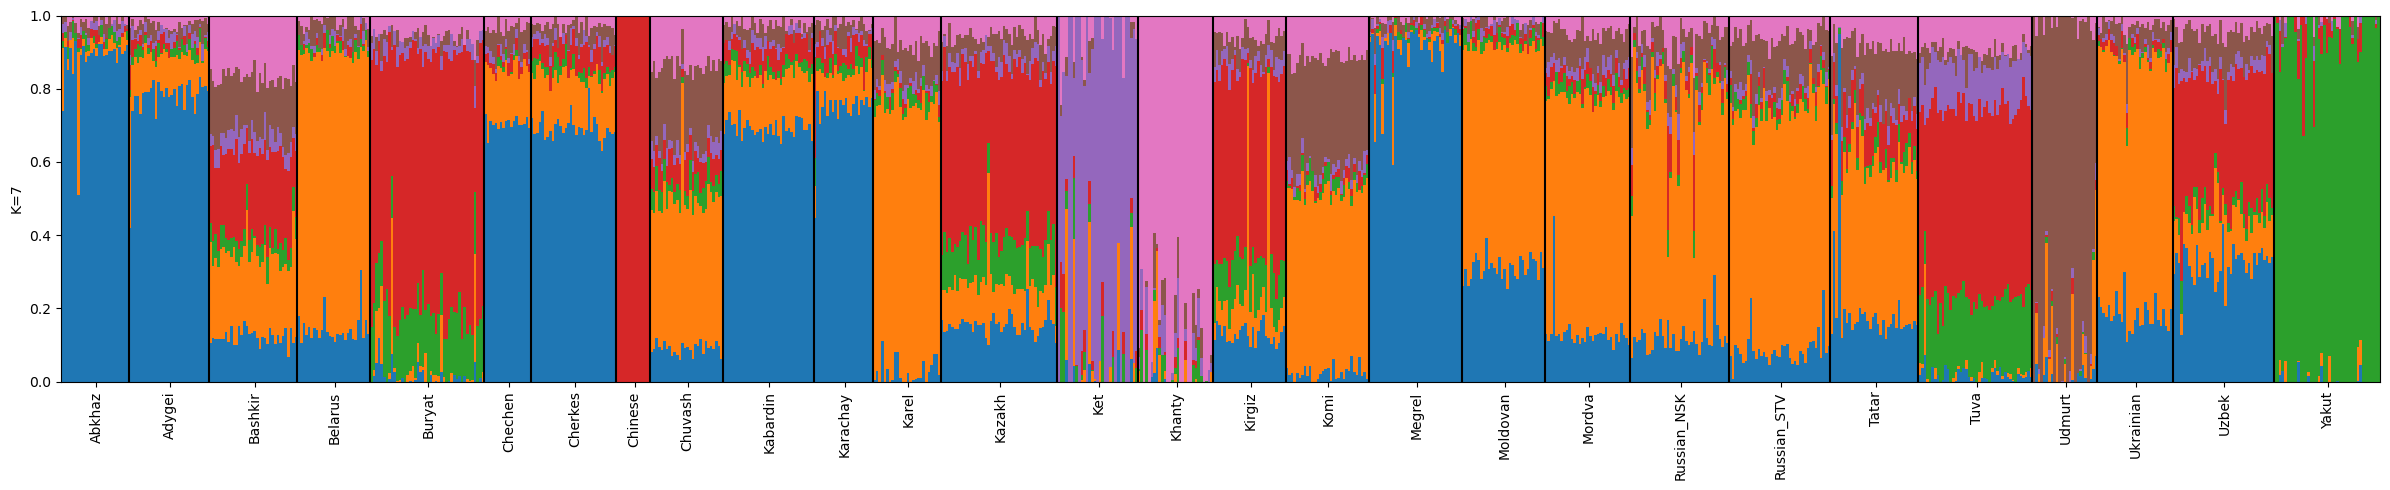

In [74]:
for k in range(2, 8):
    df3 = prepare_q_dataframe(
        k,
        OUT_DIR / "qc_pruned.fam",
        OUT_DIR / "populations.tsv",
        f"qc_pruned.{k}.Q",
    )

    plot_q_by_population(df3, k)

plt.tight_layout()
plt.show()

#### Задание 5

#### Выбор числа компонент K

Рассмотрены значения K от 2 до 7. При малых значениях K структура получается слишком грубой: популяции объединяются в крупные блоки, и различия между близкими, но не идентичными группами ещё плохо видны.

При увеличении K начинают проявляться более тонкие различия между популяциями. Однако при слишком больших K часть компонент становится менее устойчивой и начинает дробить уже существующие группы на более мелкие подкомпоненты, что усложняет интерпретацию.

В качестве основного значения K я бы выбрал `K = 4`, поскольку при этом значении уже хорошо видна популяционная структура, но модель ещё не выглядит переусложнённой. Это значение позволяет различать основные группы популяций и при этом сохраняет интерпретируемость результата. При K = 5 появляются дополнительные различия между некоторыми популяциями, однако интерпретация становится менее однозначной.


#### Вывод по ADMIXTURE-plot

ADMIXTURE-графики показывают, что исследуемые популяции не являются полностью изолированными, а представляют собой сочетание нескольких компонент происхождения. При этом для части популяций одна компонента явно доминирует, тогда как для других наблюдается более смешанный профиль.

На графиках видно, что кавказские популяции в целом имеют сходные профили компонент и отличаются от восточнославянских и сибирских групп. Восточнославянские популяции, такие как беларусы, украинцы, русские из Новосибирска и Ставрополя, также демонстрируют близкие профили между собой, что хорошо согласуется с результатами FST.

Более восточные и сибирские популяции, например Тува и якуты, заметно отличаются от западных групп и характеризуются иным распределением компонент. При этом некоторые популяции, такие как башкиры, татары, казахи, киргизы и узбеки, занимают промежуточное положение и демонстрируют смешанный профиль, что может отражать сложную историю контактов и миграций.

Таким образом, ADMIXTURE подтверждает наличие выраженной популяционной структуры и показывает, что современные популяции формировались не из полностью независимых источников, а в результате различного вклада нескольких предковых компонент.


#### Соответствие представлениям о древних донорских популяциях

Полученные ADMIXTURE-компоненты не следует напрямую интерпретировать как реальные древние популяции в буквальном смысле. Скорее, это статистические компоненты, которые отражают вклад различных предковых источников в современные группы.

Тем не менее, распределение компонент хорошо согласуется с представлением о том, что современные популяции России формировались под влиянием нескольких исторически различных источников. Для части популяций вклад одной компоненты выражен сильнее, что указывает на относительную обособленность, тогда как у других популяций профиль более смешанный, что соответствует более сложной истории миграций и контактов.

Таким образом, результаты ADMIXTURE в целом соответствуют ожиданию, что современные популяции представляют собой не изолированные единицы, а результат смешения нескольких предковых линий.


#### Сравнение с PCA

Результаты ADMIXTURE в целом согласуются с PCA из предыдущего задания. Популяции, которые должны быть близки друг к другу по PCA, как правило, имеют и сходные профили компонент на ADMIXTURE-графиках. Это особенно заметно для восточнославянских популяций, а также для части кавказских групп.

Популяции, которые на PCA должны быть удалены от основной европейской группы, например более восточные и сибирские группы, также выделяются и на ADMIXTURE-графиках. Таким образом, оба метода указывают на одну и ту же общую структуру данных.

При этом PCA и ADMIXTURE не являются полностью эквивалентными методами. PCA показывает главные оси генетической изменчивости, тогда как ADMIXTURE описывает данные через модель смеси компонент. Поэтому ADMIXTURE не повторяет PCA, а дополняет его и позволяет более наглядно представить вклад разных компонент в каждую популяцию. Также в зависимости от числа K можно найти более интересные примеси, которые может быть сложно проследить на PCA.
